In [6]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from src.models.black_scholes import BlackScholes

plt.rcParams['figure.figsize'] = (12, 8)

In [7]:
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.20

bs = BlackScholes(S0, K, T, r, sigma)

call_price = bs.price('call')
put_price = bs.price('put')

print(f"Call price: {call_price:.4f}")
print(f"Put price: {put_price:.4f}")
print(f"Put-Call parity: {call_price - put_price:.4f} vs {S0 - K * np.exp(-r * T):.4f}")

Call price: 10.4506
Put price: 5.5735
Put-Call parity: 4.8771 vs 4.8771


In [8]:
call_delta = bs.delta('call')
put_delta = bs.delta('put')
gamma = bs.gamma()
vega = bs.vega()
call_theta = bs.theta('call')
call_rho = bs.rho('call')

print(f"Delta (call): {call_delta:.4f}")
print(f"Delta (put): {put_delta:.4f}")
print(f"Gamma: {gamma:.4f}")
print(f"Vega (per 1%): {vega:.4f}")
print(f"Theta (call, per day): {call_theta:.4f}")
print(f"Rho (call, per 1%): {call_rho:.4f}")

Delta (call): 0.6368
Delta (put): -0.3632
Gamma: 0.0188
Vega (per 1%): 0.3752
Theta (call, per day): -0.0176
Rho (call, per 1%): 0.5323


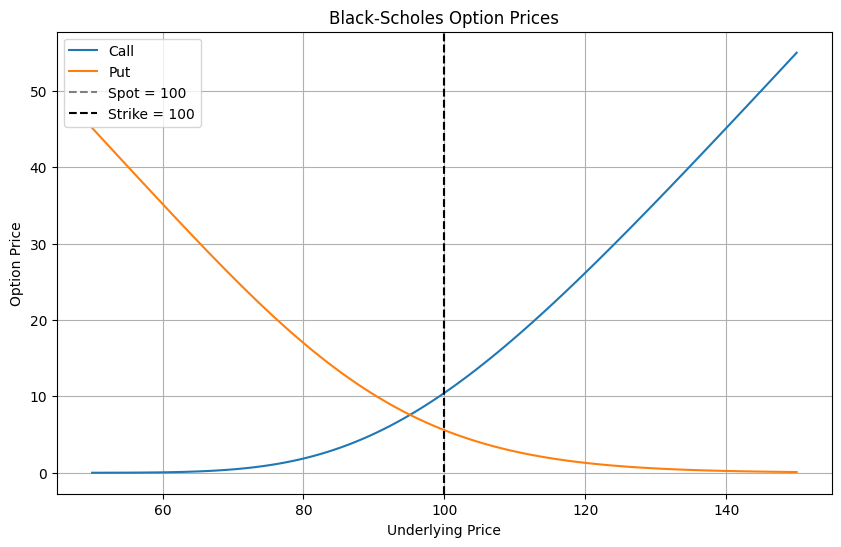

In [9]:
S_range = np.linspace(50, 150, 100)
prices_call = [BlackScholes(S, K, T, r, sigma).price('call') for S in S_range]
prices_put = [BlackScholes(S, K, T, r, sigma).price('put') for S in S_range]

plt.figure(figsize=(10, 6))
plt.plot(S_range, prices_call, label='Call')
plt.plot(S_range, prices_put, label='Put')
plt.axvline(x=S0, color='gray', linestyle='--', label=f'Spot = {S0}')
plt.axvline(x=K, color='black', linestyle='--', label=f'Strike = {K}')
plt.xlabel('Underlying Price')
plt.ylabel('Option Price')
plt.title('Black-Scholes Option Prices')
plt.legend()
plt.grid(True)
plt.show()

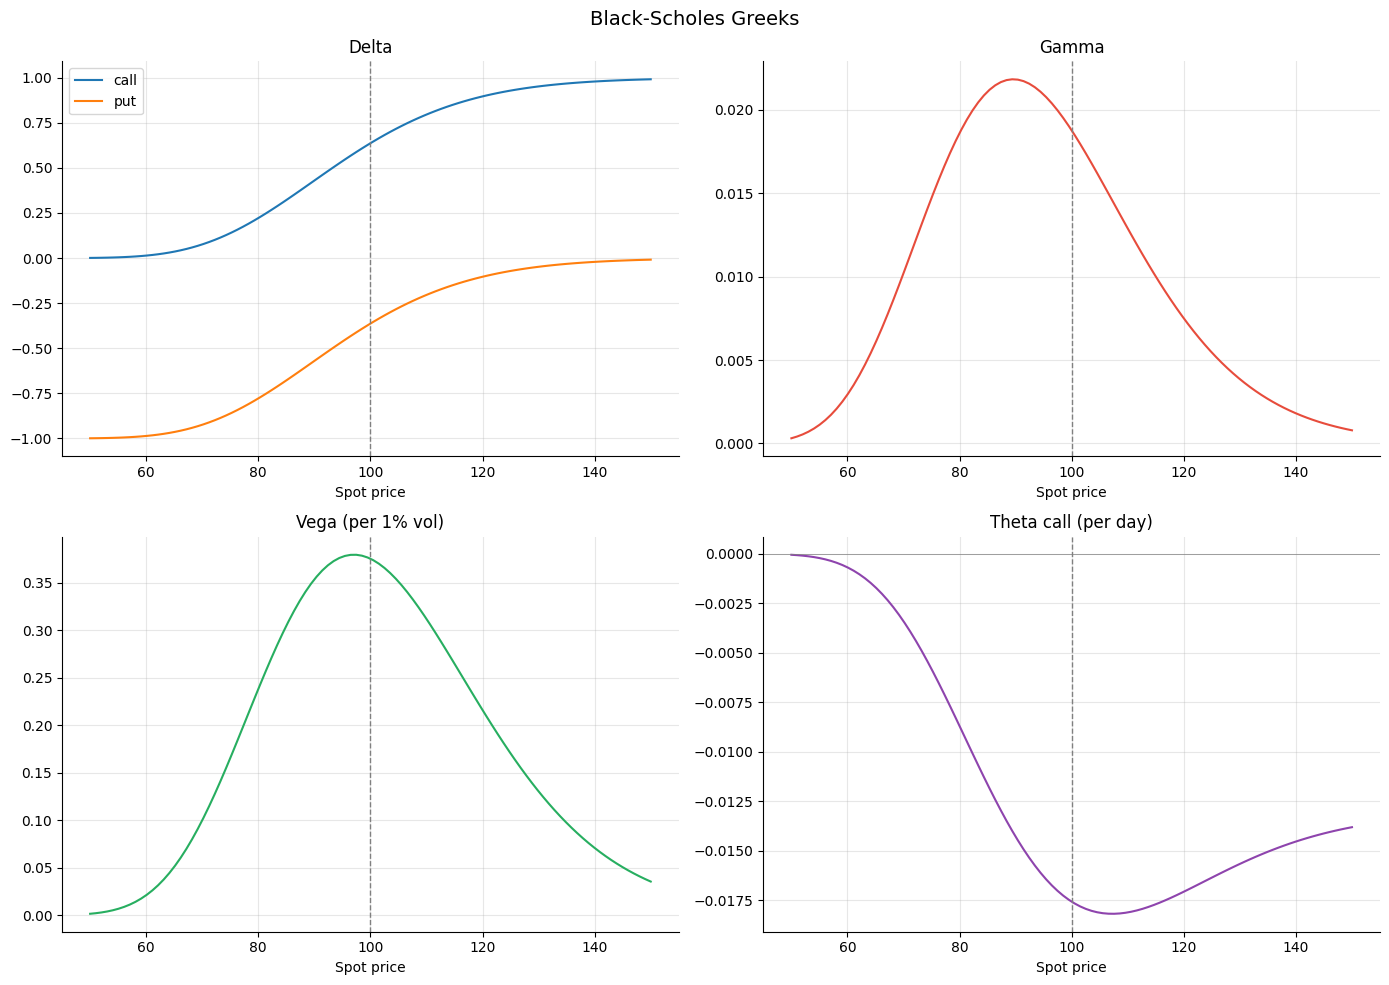

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

delta_call = [BlackScholes(S, K, T, r, sigma).delta("call") for S in S_range]
delta_put  = [BlackScholes(S, K, T, r, sigma).delta("put")  for S in S_range]
gamma_vals = [BlackScholes(S, K, T, r, sigma).gamma()        for S in S_range]
vega_vals  = [BlackScholes(S, K, T, r, sigma).vega()         for S in S_range]
theta_call = [BlackScholes(S, K, T, r, sigma).theta("call") for S in S_range]

axes[0,0].plot(S_range, delta_call, label="call")
axes[0,0].plot(S_range, delta_put,  label="put")
axes[0,0].axvline(x=K, color="gray", ls="--", lw=1)
axes[0,0].set_title("Delta")
axes[0,0].legend()

axes[0,1].plot(S_range, gamma_vals, color="#e74c3c")
axes[0,1].axvline(x=K, color="gray", ls="--", lw=1)
axes[0,1].set_title("Gamma")

axes[1,0].plot(S_range, vega_vals, color="#27ae60")
axes[1,0].axvline(x=K, color="gray", ls="--", lw=1)
axes[1,0].set_title("Vega (per 1% vol)")

axes[1,1].plot(S_range, theta_call, color="#8e44ad")
axes[1,1].axvline(x=K, color="gray", ls="--", lw=1)
axes[1,1].axhline(0, color="gray", ls="-", lw=0.5)
axes[1,1].set_title("Theta call (per day)")

for ax in axes.flat:
    ax.set_xlabel("Spot price")
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Black-Scholes Greeks", fontsize=14)
plt.tight_layout()
plt.show()
